In [41]:
!pip install scikit-learn

In [42]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [43]:
np.random.seed(42)

# Segment sizes
n_regulars = 1089
n_casual = 2156
n_infrequent = 3876

# Helper to clip values to realistic range
def clip(arr, min_val, max_val):
    return np.clip(arr, min_val, max_val).round(2)

# Segment 1 - Regulars
regulars = pd.DataFrame({
    'customer_id': range(10101, 10101 + n_regulars),
    'visit_frequency': clip(np.random.normal(18, 4, n_regulars), 10, 30).astype(int),
    'avg_spend': clip(np.random.normal(17.5, 0.8, n_regulars), 16.23, 25.72),
    'time_of_visit': np.random.choice(['lunch', 'dinner'], n_regulars, p=[0.6, 0.4]),
    'day_preference': np.random.choice(['weekday', 'weekend'], n_regulars, p=[0.75, 0.25]),
    'segment': 'Regular'
})

# Segment 2 - Casual
casual = pd.DataFrame({
    'customer_id': range(10101 + n_regulars, 10101 + n_regulars + n_casual),
    'visit_frequency': clip(np.random.normal(6, 1.5, n_casual), 3, 10).astype(int),
    'avg_spend': clip(np.random.normal(19.5, 1.5, n_casual), 17.34, 28.43),
    'time_of_visit': np.random.choice(['lunch', 'dinner'], n_casual, p=[0.55, 0.45]),
    'day_preference': np.random.choice(['weekday', 'weekend'], n_casual, p=[0.65, 0.35]),
    'segment': 'Casual'
})

# Segment 3 - Infrequent
infrequent = pd.DataFrame({
    'customer_id': range(10101 + n_regulars + n_casual, 10101 + n_regulars + n_casual + n_infrequent),
    'visit_frequency': clip(np.random.normal(2.5, 0.8, n_infrequent), 1, 5).astype(int),
    'avg_spend': clip(np.random.normal(24, 2, n_infrequent), 19.47, 36.18),
    'time_of_visit': np.random.choice(['lunch', 'dinner'], n_infrequent, p=[0.5, 0.5]),
    'day_preference': np.random.choice(['weekday', 'weekend'], n_infrequent, p=[0.55, 0.45]),
    'segment': 'Infrequent'
})

# Combine all segments
df_customers = pd.concat([regulars, casual, infrequent]).reset_index(drop=True)

print(df_customers.head(10))
print(df_customers.shape)
print(df_customers['segment'].value_counts())

   customer_id  visit_frequency  avg_spend time_of_visit day_preference  \
0        10101               19      17.34         lunch        weekday   
1        10102               17      17.44        dinner        weekday   
2        10103               20      17.47         lunch        weekend   
3        10104               24      18.08         lunch        weekend   
4        10105               17      17.54        dinner        weekday   
5        10106               17      18.09         lunch        weekday   
6        10107               24      17.44         lunch        weekday   
7        10108               21      17.56         lunch        weekday   
8        10109               16      16.23         lunch        weekday   
9        10110               20      18.23         lunch        weekday   

   segment  
0  Regular  
1  Regular  
2  Regular  
3  Regular  
4  Regular  
5  Regular  
6  Regular  
7  Regular  
8  Regular  
9  Regular  
(7121, 6)
segment
Infrequent   

In [44]:
print("REGULARS:")
print(df_customers[df_customers['segment'] == 'Regular'].describe())

print("\nCASUAL:")
print(df_customers[df_customers['segment'] == 'Casual'].describe())

print("\nINFREQUENT:")
print(df_customers[df_customers['segment'] == 'Infrequent'].describe())

REGULARS:
        customer_id  visit_frequency    avg_spend
count   1089.000000      1089.000000  1089.000000
mean   10645.000000        17.660239    17.549789
std      314.511526         3.856608     0.755506
min    10101.000000        10.000000    16.230000
25%    10373.000000        15.000000    17.000000
50%    10645.000000        18.000000    17.520000
75%    10917.000000        20.000000    18.050000
max    11189.000000        30.000000    20.050000

CASUAL:
        customer_id  visit_frequency    avg_spend
count   2156.000000      2156.000000  2156.000000
mean   12267.500000         5.485158    19.541976
std      622.527911         1.469335     1.444441
min    11190.000000         3.000000    17.340000
25%    11728.750000         4.000000    18.417500
50%    12267.500000         5.000000    19.450000
75%    12806.250000         6.000000    20.560000
max    13345.000000        10.000000    24.790000

INFREQUENT:
       customer_id  visit_frequency    avg_spend
count   3876.00000 

In [45]:
# Calculate total revenue per segment (annual now)
df_customers['annual_revenue'] = df_customers['visit_frequency'] * df_customers['avg_spend']

revenue_by_segment = df_customers.groupby('segment').agg(
    unique_customers=('customer_id', 'count'),
    avg_visit_frequency=('visit_frequency', 'mean'),
    avg_spend=('avg_spend', 'mean'),
    total_annual_revenue=('annual_revenue', 'sum')
).round(2)

revenue_by_segment['revenue_pct'] = (revenue_by_segment['total_annual_revenue'] / revenue_by_segment['total_annual_revenue'].sum() * 100).round(2)

print(revenue_by_segment)
print(f'\nTotal Annual Revenue: ${df_customers["annual_revenue"].sum():,.2f}')

            unique_customers  avg_visit_frequency  avg_spend  \
segment                                                        
Casual                  2156                 5.49      19.54   
Infrequent              3876                 2.05      24.05   
Regular                 1089                17.66      17.55   

            total_annual_revenue  revenue_pct  
segment                                        
Casual                 231021.87        30.40  
Infrequent             191170.82        25.16  
Regular                337704.28        44.44  

Total Annual Revenue: $759,896.97


In [46]:
# Convert text columns to numeric
df_customers['time_encoded'] = df_customers['time_of_visit'].map({
    'lunch': 0,
    'dinner': 1
})

df_customers['day_encoded'] = df_customers['day_preference'].map({
    'weekday': 0,
    'weekend': 1
})

print(df_customers.columns.tolist())
print(df_customers.head())

['customer_id', 'visit_frequency', 'avg_spend', 'time_of_visit', 'day_preference', 'segment', 'annual_revenue', 'time_encoded', 'day_encoded']
   customer_id  visit_frequency  avg_spend time_of_visit day_preference  \
0        10101               19      17.34         lunch        weekday   
1        10102               17      17.44        dinner        weekday   
2        10103               20      17.47         lunch        weekend   
3        10104               24      18.08         lunch        weekend   
4        10105               17      17.54        dinner        weekday   

   segment  annual_revenue  time_encoded  day_encoded  
0  Regular          329.46             0            0  
1  Regular          296.48             1            0  
2  Regular          349.40             0            1  
3  Regular          433.92             0            1  
4  Regular          298.18             1            0  


In [38]:
# Select features for clustering
features = ['visit_frequency']

# Scale the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_customers[features])


print("Scaled data shape:", df_scaled.shape)
print("First 5 rows:")
print(df_scaled[:5])

Scaled data shape: (7121, 1)
First 5 rows:
[[2.37715436]
 [2.02555573]
 [2.55295367]
 [3.25615094]
 [2.02555573]]


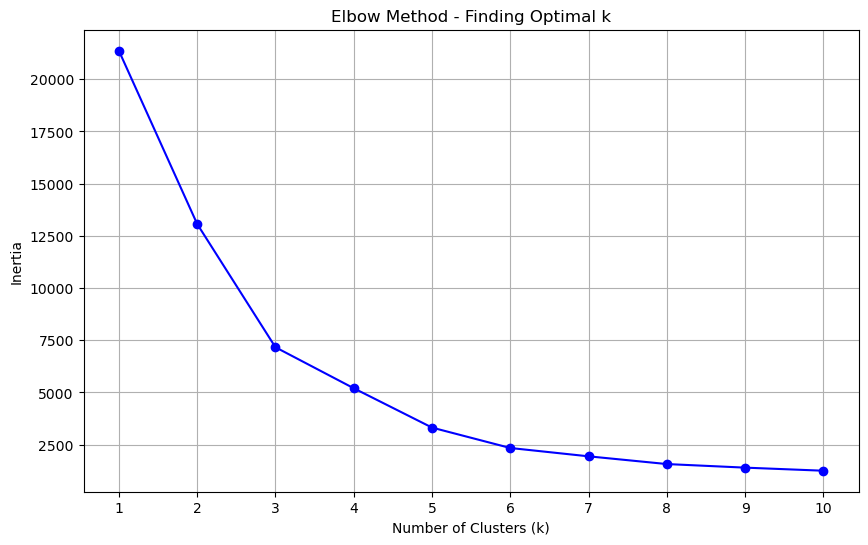

In [37]:
# Try different values of k
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Finding Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [39]:
# Run k-means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(df_scaled)

# Add cluster labels to original dataframe
df_customers['cluster'] = kmeans.labels_

# Look at cluster characteristics
cluster_summary = df_customers.groupby('cluster').agg(
    count=('customer_id', 'count'),
    avg_visit_frequency=('visit_frequency', 'mean'),
    avg_spend=('avg_spend', 'mean'),
    pct_weekend=('day_encoded', 'mean'),
    pct_dinner=('time_encoded', 'mean')
).round(2)

print(cluster_summary)

         count  avg_visit_frequency  avg_spend  pct_weekend  pct_dinner
cluster                                                                
0         4418                 2.24      23.49         0.43        0.49
1          984                18.36      17.55         0.24        0.39
2         1719                 6.43      19.42         0.36        0.45


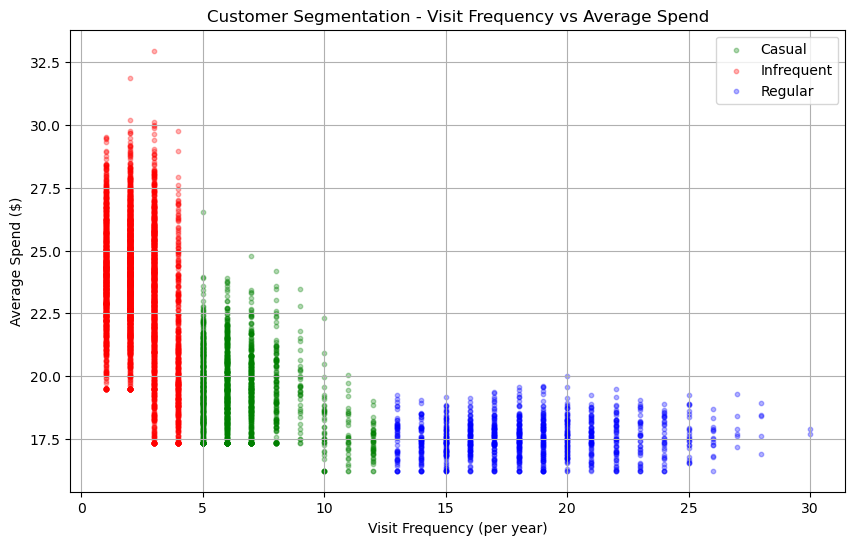

In [40]:

# Assign meaningful names to clusters
cluster_names = {1: 'Regular', 2: 'Casual', 0: 'Infrequent'}
df_customers['cluster_name'] = df_customers['cluster'].map(cluster_names)

# Scatter plot - visit frequency vs avg spend colored by cluster
plt.figure(figsize=(10, 6))

colors = {'Regular': 'blue', 'Casual': 'green', 'Infrequent': 'red'}

for name, group in df_customers.groupby('cluster_name'):
    plt.scatter(
        group['visit_frequency'],
        group['avg_spend'],
        c=colors[name],
        label=name,
        alpha=0.3,
        s=10
    )

plt.xlabel('Visit Frequency (per year)')
plt.ylabel('Average Spend ($)')
plt.title('Customer Segmentation - Visit Frequency vs Average Spend')
plt.legend()
plt.grid(True)
plt.show()